# Analog I/O Calibration
Sweeps the full DAC output range on a selected channel, reads back on a selected ADC pin, then plots both and computes error.

**Wiring:** connect DAC output pin → ADC input pin before running.

In [9]:
import serial
import struct
import time
import numpy as np
import matplotlib.pyplot as plt

In [10]:
# ── Configuration ──────────────────────────────────────────────────────────────
SERIAL_PORT   = '/dev/ttyACM1'
BAUD_RATE     = 1500000

DAC_CHANNEL   = 1          # Analog output channel (1-4)
ADC_PIN       = 1          # Analog input pin      (1-4)

NUM_STEPS     = 100        # Number of points across full DAC range
SETTLE_MS     = 5          # ms to wait after writing before reading

DAC_MAX       = 0xFFFF     # 16-bit DAC
VREF_MV       = 5000       # DAC reference in mV
OP_BYTE       = 0x33
# ──────────────────────────────────────────────────────────────────────────────

ser = serial.Serial(SERIAL_PORT, baudrate=BAUD_RATE, timeout=0.05)
print(f"Connected to {SERIAL_PORT} at {BAUD_RATE} baud")

Connected to /dev/ttyACM1 at 1500000 baud


In [11]:
def analog_write(channel: int, dac_value: int):
    """Send DAC write command and return firmware ack (7 bytes)."""
    dac_value = max(0, min(dac_value, DAC_MAX))
    cmd = struct.pack('>BBBBH', OP_BYTE, 0x01, 0x01, channel, dac_value)
    ser.flushInput()
    ser.write(cmd)
    return ser.read(7)


def analog_read(pin: int) -> int:
    """Read ADC pin and return voltage in mV (as reported by firmware)."""
    cmd = struct.pack('>BBBBH', OP_BYTE, 0x01, 0x00, pin, 0x0000)
    ser.flushInput()
    ser.write(cmd)
    resp = ser.read(7)
    if len(resp) < 7 or resp[0] != OP_BYTE or resp[6] != 0x0A:
        return None
    # Firmware sends: data[4]=voltage>>8, data[5]=voltage&0x0F
    # Note: lower nibble only due to firmware mask — precision ~240 mV in worst case
    voltage_mv = (resp[4] << 8) | resp[5]
    return voltage_mv

In [12]:
dac_values   = np.linspace(0, DAC_MAX, NUM_STEPS, dtype=int)
set_mv       = []   # Expected output voltage (mV)
read_mv      = []   # Measured ADC voltage (mV)
failed       = 0

print(f"Sweeping DAC channel {DAC_CHANNEL} → ADC pin {ADC_PIN} ({NUM_STEPS} points)...")

for dac in dac_values:
    analog_write(DAC_CHANNEL, int(dac))
    time.sleep(SETTLE_MS / 1000.0)
    v = analog_read(ADC_PIN)
    expected = int(dac) / DAC_MAX * VREF_MV
    set_mv.append(expected)
    if v is not None:
        read_mv.append(v)
    else:
        read_mv.append(float('nan'))
        failed += 1

set_mv  = np.array(set_mv,  dtype=float)
read_mv = np.array(read_mv, dtype=float)
error   = read_mv - set_mv

print(f"Done. Failed reads: {failed}/{NUM_STEPS}")

Sweeping DAC channel 1 → ADC pin 1 (100 points)...
Done. Failed reads: 0/100


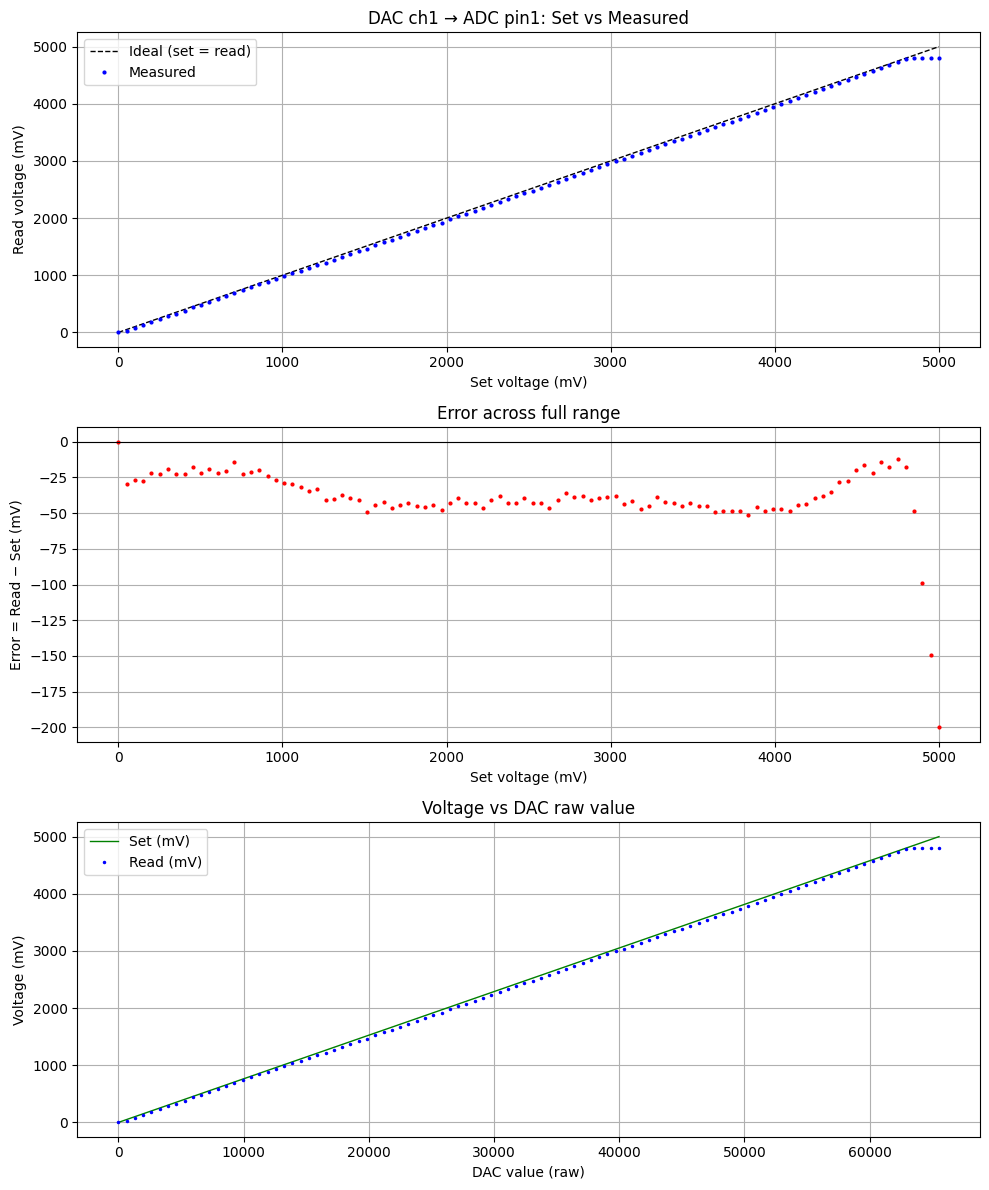

In [13]:
fig, axes = plt.subplots(3, 1, figsize=(10, 12))

# ── Plot 1: Set vs Read ────────────────────────────────────────────────────────
ax = axes[0]
ax.plot(set_mv, set_mv, 'k--', linewidth=1, label='Ideal (set = read)')
ax.plot(set_mv, read_mv, 'b.', markersize=4, label='Measured')
ax.set_xlabel('Set voltage (mV)')
ax.set_ylabel('Read voltage (mV)')
ax.set_title(f'DAC ch{DAC_CHANNEL} → ADC pin{ADC_PIN}: Set vs Measured')
ax.legend()
ax.grid(True)

# ── Plot 2: Error vs Set voltage ───────────────────────────────────────────────
ax = axes[1]
ax.plot(set_mv, error, 'r.', markersize=4)
ax.axhline(0, color='k', linewidth=0.8)
ax.set_xlabel('Set voltage (mV)')
ax.set_ylabel('Error = Read − Set (mV)')
ax.set_title('Error across full range')
ax.grid(True)

# ── Plot 3: Raw DAC value vs both voltages ─────────────────────────────────────
ax = axes[2]
ax.plot(dac_values, set_mv,  'g-', linewidth=1, label='Set (mV)')
ax.plot(dac_values, read_mv, 'b.', markersize=3, label='Read (mV)')
ax.set_xlabel('DAC value (raw)')
ax.set_ylabel('Voltage (mV)')
ax.set_title('Voltage vs DAC raw value')
ax.legend()
ax.grid(True)

plt.tight_layout()
plt.savefig('analog_cal.png', dpi=150)
plt.show()

In [ ]:
valid = ~np.isnan(error)
e = error[valid]

print(f"--- Error statistics ({valid.sum()} valid points) ---")
print(f"  Mean error   : {e.mean():+.1f} mV")
print(f"  Std dev      : {e.std():.1f} mV")
print(f"  Min error    : {e.min():+.1f} mV")
print(f"  Max error    : {e.max():+.1f} mV")
print(f"  Peak-to-peak : {e.max() - e.min():.1f} mV")
print(f"  RMSE         : {np.sqrt((e**2).mean()):.1f} mV")

--- Error statistics (100 valid points) ---
  Mean error   : -39.3 mV
  Std dev      : 23.4 mV
  Min error    : -200.0 mV
  Max error    : +0.0 mV
  Peak-to-peak : 200.0 mV
  RMSE         : 45.7 mV

Note: ADC firmware masks low byte to 4 bits (voltage & 0x0F),
so read resolution is coarse — up to ~240 mV quantisation error.


In [15]:
# Close serial when done
ser.close()
print("Serial closed")

Serial closed
